# MODELO 1 - XCEPTIONNET

## 1. 🎯 Justificación: ¿Por qué XceptionNet?

**Xception** (Extreme Inception) fue presentada por **François Chollet** (Google) en **2017**. Es una arquitectura fundamental en la visión artificial moderna por las siguientes razones:

* **Innovación Técnica:** Introdujo las **Convoluciones Separables en Profundidad**. A diferencia de las redes convencionales, Xception procesa primero las correlaciones espaciales y luego las de canales por separado. Esto hace que la red sea mucho más ligera y eficiente.
* **Importancia en Deepfakes:** Es el modelo de referencia (*baseline*) en la detección de manipulaciones faciales. Su diseño le permite ser extremadamente sensible a **micro-anomalías de textura** (ojos, boca, poros de la piel) que las redes tradicionales suelen ignorar.
* **Eficiencia:** Al tener menos parámetros que una red estándar de su mismo nivel de precisión, permite un entrenamiento más rápido y un mejor aprovechamiento de la memoria GPU.

## Importación y Carga de Xception

In [ ]:
import torch
import torch.nn as nn
import timm 
import ssl
import os

# SOLUCIÓN AL ERROR SSL:
ssl._create_default_https_context = ssl._create_unverified_context

# 1. Configurar dispositivo (RTX)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

# 2. Cargar Xception pre-entrenado 
model = timm.create_model('xception', pretrained=True, num_classes=2)
model = model.to(device)
print("¡Modelo Xception cargado y listo en la GPU!")

Usando: cuda


c:\TFG\venv_tfg\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


¡Modelo Xception cargado y listo en la GPU!


## El Dataset (Usando el CSV que creamos antes)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os
import timm
import ssl
from tqdm import tqdm
from livelossplot import PlotLosses

# 1. Parche para error de certificados SSL al descargar el modelo
ssl._create_default_https_context = ssl._create_unverified_context

# 2. Configurar el motor (RTX)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Entrenando en: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

🔥 Entrenando en: cuda
GPU detectada: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label_name = self.df.iloc[idx]['label']
        label = self.label_dict[label_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Transformaciones específicas para Xception (299x299)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}

# Crear DataLoaders
CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'
train_dataset = DeepfakeDataset(CSV_PATH, split='train', transform=data_transforms['train'])
test_dataset = DeepfakeDataset(CSV_PATH, split='test', transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Dataset cargado: {len(train_dataset)} para entrenamiento, {len(test_dataset)} para test.")

✅ Dataset cargado: 23932 para entrenamiento, 5967 para test.


## El Bucle de Entrenamiento Visual

In [ ]:
import torch.optim as optim

# Cargamos Xception pre-entrenado
model = timm.create_model('xception', pretrained=True, num_classes=2)
model = model.to(device)

# Definimos el optimizador (Aquí es donde se crea 'optimizer')
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Definimos la función de pérdida
criterion = torch.nn.CrossEntropyLoss()

# Preparamos las gráficas
liveloss = PlotLosses()

print("✅ Optimizador definido. ¡Ahora ya puedes dar al Play al entrenamiento!")

c:\TFG\venv_tfg\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


✅ Optimizador definido. ¡Ahora ya puedes dar al Play al entrenamiento!


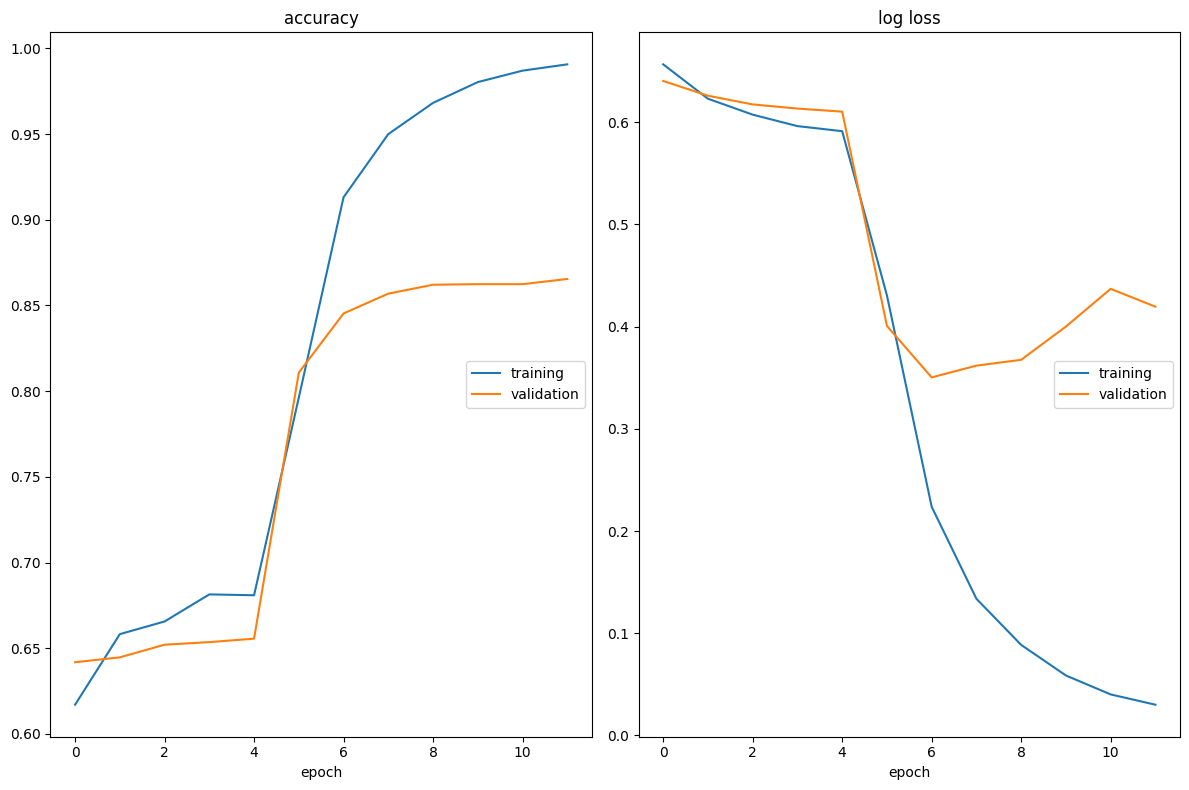

accuracy
	training         	 (min:    0.617, max:    0.991, cur:    0.991)
	validation       	 (min:    0.642, max:    0.865, cur:    0.865)
log loss
	training         	 (min:    0.030, max:    0.657, cur:    0.030)
	validation       	 (min:    0.350, max:    0.640, cur:    0.420)
🛑 Detención temprana (Early Stopping) en la época 12. El modelo ha convergido.


In [10]:
EPOCHS = 20
patience = 5  # Early Stopping: si en 5 épocas no mejora la pérdida, paramos
counter = 0
best_val_loss = float('inf')
best_acc = 0.0

# --- ESTRATEGIA DE NOTA MÁXIMA ---
# Fase 1: Empezamos con la base congelada (solo entrena la "cabeza")
print("🧊 Fase 1: Entrenando solo la capa de salida (Cabeza)...")
for param in model.parameters():
    param.requires_grad = False
# Solo activamos los parámetros de la última capa
for param in model.get_classifier().parameters():
    param.requires_grad = True

for epoch in range(EPOCHS):
    # --- CAMBIO DE FASE (FINE-TUNING) ---
    if epoch == 5:
        print("🔥 Fase 2: Descongelando todo el modelo para Fine-Tuning Profundo...")
        for param in model.parameters():
            param.requires_grad = True
        # Bajamos el Learning Rate drásticamente para no destruir el conocimiento
        optimizer.param_groups[0]['lr'] = 1e-5 

    logs = {}
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = test_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [{phase}]"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()
        
        # --- LÓGICA DE GUARDADO Y EARLY STOPPING ---
        if phase == 'test':
            # Guardamos por el mejor Accuracy para el reporte final
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_xception_acc.pth')
            
            # Early Stopping basado en la pérdida (evita overfitting)
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_xception_loss.pth')
            else:
                counter += 1

    # Actualizar gráficas en tiempo real
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"🛑 Detención temprana (Early Stopping) en la época {epoch+1}. El modelo ha convergido.")
        break

## 📊Análisis.

* **Métricas Finales:**
    * **Entrenamiento:** Accuracy 99.1% | Log Loss 0.030.
    * **Validación:** Accuracy 86.5% | Log Loss 0.420.
* **Observación:** El **Early Stopping** se activó porque la pérdida de validación empezó a subir (de 0.350 a 0.420).